# ROS Bag File Explorer

Inspect the ROS2 bag at `bag files/park_1_bag/park_1.bag` using the `rosbags` library.

This notebook reports bag duration, total message count, a per-topic table (sorted by message count descending), and specific topic existence checks.

## Imports & open the reader

We use `rosbags.highlevel.AnyReader`, which transparently supports ROS1 `.bag` files. The path is passed as a `pathlib.Path`.

In [3]:
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
from rosbags.highlevel import AnyReader

BAG_PATH = Path(r"bag files/park_1_bag/park_1.bag")

if not BAG_PATH.exists():
    raise FileNotFoundError(f"Bag file not found: {BAG_PATH}")

print(f"Bag file: {BAG_PATH}")
print(f"Size:     {BAG_PATH.stat().st_size / (1024 ** 2):.2f} MiB")

Bag file: bag files/park_1_bag/park_1.bag
Size:     42533.09 MiB


## 1. Bag duration & start/end time

`AnyReader` exposes `start_time` and `end_time` as nanoseconds since the Unix epoch. We convert them to human-readable UTC datetimes and compute the duration in seconds.

In [4]:
def ns_to_datetime(ns):
    """Convert nanoseconds-since-epoch to a timezone-aware UTC datetime."""
    return datetime.fromtimestamp(ns / 1e9, tz=timezone.utc)


def format_duration(seconds):
    """Human-readable H:MM:SS(.mmm) string for a duration in seconds."""
    total_ms = int(round(seconds * 1000))
    hours, rem_ms = divmod(total_ms, 3_600_000)
    minutes, rem_ms = divmod(rem_ms, 60_000)
    secs, millis = divmod(rem_ms, 1000)
    return f"{hours:d}h {minutes:02d}m {secs:02d}.{millis:03d}s"


with AnyReader([BAG_PATH]) as reader:
    start_ns = reader.start_time
    end_ns = reader.end_time
    duration_s = (end_ns - start_ns) / 1e9

    start_dt = ns_to_datetime(start_ns)
    end_dt = ns_to_datetime(end_ns)

print(f"Start time: {start_ns} ns  ->  {start_dt.isoformat()}")
print(f"End time:   {end_ns} ns  ->  {end_dt.isoformat()}")
print(f"Duration:   {duration_s:.3f} seconds  ({format_duration(duration_s)})")

Start time: 18440505000000 ns  ->  1970-01-01T05:07:20.505000+00:00
End time:   18694001000001 ns  ->  1970-01-01T05:11:34.001000+00:00
Duration:   253.496 seconds  (0h 04m 13.496s)


## 2. Total message count

The reader exposes `message_count` (the total across all topics). We also cross-check it by summing each connection's `msgcount`.

In [5]:
with AnyReader([BAG_PATH]) as reader:
    total_messages = reader.message_count
    total_from_connections = sum(conn.msgcount for conn in reader.connections)

print(f"Total messages (reader.message_count):        {total_messages}")
print(f"Total messages (sum of connection.msgcount):  {total_from_connections}")

Total messages (reader.message_count):        406074
Total messages (sum of connection.msgcount):  406074


## 3. Per-topic table

One row per topic with its message type and message count. Multiple connections can share a topic, so counts are aggregated per topic. Sorted by message count **descending** (most messages first).

In [6]:
with AnyReader([BAG_PATH]) as reader:
    topic_rows = {}
    for conn in reader.connections:
        row = topic_rows.setdefault(
            conn.topic, {"topic": conn.topic, "msgtype": conn.msgtype, "count": 0}
        )
        row["count"] += conn.msgcount

topics_df = pd.DataFrame(topic_rows.values())
topics_df = topics_df.sort_values("count", ascending=False).reset_index(drop=True)
topics_df.columns = ["Topic", "Message Type", "Message Count"]

print(f"{len(topics_df)} topics\n")
topics_df

37 topics



,Topic,Message Type,Message Count
0,/gazebo/model_states,gazebo_msgs/msg/ModelStates,253500
1,/tf,tf2_msgs/msg/TFMessage,25350
2,/os0_cloud_node/imu/bias,sensor_msgs/msg/Imu,25350
3,/os0_cloud_node/imu,sensor_msgs/msg/Imu,25350
4,/imu/data,sensor_msgs/msg/Imu,12675
5,/imu/data/bias,sensor_msgs/msg/Imu,12675
6,/odometry/filtered,nav_msgs/msg/Odometry,12675
7,stereo/camera/right/real/compressed,sensor_msgs/msg/CompressedImage,6337
8,stereo/camera/left/real/compressed,sensor_msgs/msg/CompressedImage,6337
9,/stereo/camera/right/tag/image_raw,sensor_msgs/msg/Image,6336


## 4. Specific existence checks

Check for any `syscall` topic, `/tf`, and `/tf_static`. Prints `True`/`False` and the matching topic name(s) where present.

In [7]:
with AnyReader([BAG_PATH]) as reader:
    all_topics = sorted({conn.topic for conn in reader.connections})

# 'syscall' anywhere in the topic name
syscall_matches = [t for t in all_topics if "syscall" in t]
has_syscall = len(syscall_matches) > 0
print(f"Any 'syscall' topic present: {has_syscall}")
if has_syscall:
    for t in syscall_matches:
        print(f"    matched: {t}")

# /tf
has_tf = "/tf" in all_topics
print(f"'/tf' present:               {has_tf}" + ("    (/tf)" if has_tf else ""))

# /tf_static
has_tf_static = "/tf_static" in all_topics
print(
    f"'/tf_static' present:        {has_tf_static}"
    + ("    (/tf_static)" if has_tf_static else "")
)

Any 'syscall' topic present: False
'/tf' present:               True    (/tf)
'/tf_static' present:        True    (/tf_static)


## 5. `/tf_static` frame tree

`/tf_static` carries the fixed sensor-mounting transforms, published once at startup. We read that single message and dump every transform (parent -> child, translation, rotation) to reveal the frame tree.

In [8]:
with AnyReader([BAG_PATH]) as reader:
    tf_static_conns = [c for c in reader.connections if c.topic == "/tf_static"]

    if not tf_static_conns:
        raise RuntimeError("No connection found for topic '/tf_static'")

    transforms = []
    for connection, timestamp, rawdata in reader.messages(connections=tf_static_conns):
        msg = reader.deserialize(rawdata, connection.msgtype)
        transforms.extend(msg.transforms)

print(f"/tf_static contains {len(transforms)} transform(s):\n")

for i, transform in enumerate(transforms, start=1):
    parent = transform.header.frame_id
    child = transform.child_frame_id
    t = transform.transform.translation
    q = transform.transform.rotation

    print(f"[{i}] {parent} -> {child}")
    print(f"    translation: x={t.x:.6f}, y={t.y:.6f}, z={t.z:.6f}")
    print(f"    rotation:    x={q.x:.6f}, y={q.y:.6f}, z={q.z:.6f}, w={q.w:.6f}")
    print()

/tf_static contains 18 transform(s):

[1] base_link -> GNSS_link
    translation: x=0.100000, y=0.000000, z=0.920000
    rotation:    x=0.000000, y=0.000000, z=0.000000, w=1.000000

[2] base_link -> base_footprint
    translation: x=0.000000, y=0.000000, z=-0.132280
    rotation:    x=0.000000, y=0.000000, z=0.000000, w=1.000000

[3] base_link -> front_bumper_link
    translation: x=0.480000, y=0.000000, z=0.091000
    rotation:    x=0.000000, y=0.000000, z=0.000000, w=1.000000

[4] base_link -> imu_link
    translation: x=0.190000, y=0.000000, z=0.149000
    rotation:    x=0.707108, y=0.000003, z=0.707105, w=-0.000003

[5] base_link -> inertial_link
    translation: x=0.000000, y=0.000000, z=0.000000
    rotation:    x=0.000000, y=0.000000, z=0.000000, w=1.000000

[6] base_link -> left_camera
    translation: x=0.150000, y=0.060000, z=0.720000
    rotation:    x=0.000000, y=0.000000, z=0.000000, w=1.000000

[7] os0_sensor -> os0_imu
    translation: x=0.006253, y=-0.011775, z=0.007645

## 6. Sample message from each topic

For each **meaningful** data topic (everything except the 19 near-identical `dynamic_reconfigure` config topics ending in `/parameter_descriptions` or `/parameter_updates`), we read and print the **first** message so its structure can be explained.

Large messages are kept to **structure + summary** rather than raw content:

- `PointCloud2` -> dimensions, step sizes, field layout, byte count (no raw `data`).
- `Image` / `CompressedImage` -> dimensions, encoding/format, byte count (no raw `data`).
- `ModelStates` -> model count, model names, and only the first pose (no full pose/twist arrays).
- Everything else (Imu, Odometry, NavSatFix, Twist, Float32, Float64MultiArray, TFMessage, ...) -> printed in full; these are small.

Topics are visited in descending message-count order (same ordering as the per-topic table). The 19 config topics are sampled separately in the next section.

In [9]:
def _print_header_stamp(msg):
    """Print the message header timestamp if the message has a `.header`."""
    header = getattr(msg, "header", None)
    if header is not None and hasattr(header, "stamp"):
        stamp = header.stamp
        stamp_ns = stamp.sec * 1_000_000_000 + stamp.nanosec
        print(f"    header.stamp: {stamp.sec}.{stamp.nanosec:09d}  ({stamp_ns} ns)")
        if getattr(header, "frame_id", ""):
            print(f"    header.frame_id: {header.frame_id}")


def summarize_msg(topic, msgtype, msg):
    """Print a message: STRUCTURE + SUMMARY for big types, full repr otherwise."""
    print(f"Topic:        {topic}")
    print(f"Message type: {msgtype}")
    _print_header_stamp(msg)

    if msgtype == "sensor_msgs/msg/PointCloud2":
        print(f"    height:     {msg.height}")
        print(f"    width:      {msg.width}")
        print(f"    point_step: {msg.point_step}")
        print(f"    row_step:   {msg.row_step}")
        print(f"    is_dense:   {msg.is_dense}")
        print(f"    data:       {len(msg.data)} bytes (not shown)")
        print(f"    fields ({len(msg.fields)}):")
        for f in msg.fields:
            print(f"        name={f.name!r}, offset={f.offset}, datatype={f.datatype}, count={f.count}")

    elif msgtype in ("sensor_msgs/msg/Image", "sensor_msgs/msg/CompressedImage"):
        if msgtype == "sensor_msgs/msg/Image":
            print(f"    height:   {msg.height}")
            print(f"    width:    {msg.width}")
            print(f"    encoding: {msg.encoding}")
            print(f"    step:     {msg.step}")
        else:  # CompressedImage
            print(f"    format:   {msg.format}")
        print(f"    data:     {len(msg.data)} bytes (not shown)")

    elif msgtype == "gazebo_msgs/msg/ModelStates":
        print(f"    models: {len(msg.name)}")
        print(f"    names:  {list(msg.name)}")
        if len(msg.pose) > 0:
            print(f"    pose[0]: {msg.pose[0]!r}")
        else:
            print("    pose[]: (empty)")

    else:
        print("    message:")
        print(f"{msg!r}")


In [10]:
CONFIG_SUFFIXES = ("/parameter_descriptions", "/parameter_updates")


def is_config_topic(topic):
    """True for the near-identical dynamic_reconfigure config topics."""
    return topic.endswith(CONFIG_SUFFIXES)


with AnyReader([BAG_PATH]) as reader:
    # Aggregate connections and counts per topic (same approach as section 3).
    topic_info = {}
    for conn in reader.connections:
        info = topic_info.setdefault(
            conn.topic, {"msgtype": conn.msgtype, "count": 0, "conns": []}
        )
        info["count"] += conn.msgcount
        info["conns"].append(conn)

    # Meaningful topics: exclude the config topics, sort by count descending.
    meaningful = [t for t in topic_info if not is_config_topic(t)]
    meaningful.sort(key=lambda t: topic_info[t]["count"], reverse=True)

    sep = "=" * 100
    for topic in meaningful:
        info = topic_info[topic]
        print(sep)

        if info["count"] == 0:
            print(f"Topic:        {topic}")
            print(f"Message type: {info['msgtype']}")
            print("    (no messages on this topic â€” skipped)")
            continue

        # Read only the first message across this topic's connection(s).
        first = None
        for connection, timestamp, rawdata in reader.messages(connections=info["conns"]):
            msg = reader.deserialize(rawdata, connection.msgtype)
            first = (connection.msgtype, msg)
            break

        if first is None:
            print(f"Topic:        {topic}")
            print(f"Message type: {info['msgtype']}")
            print("    (no message could be read â€” skipped)")
            continue

        summarize_msg(topic, first[0], first[1])

    print(sep)
    print(f"Sampled {len(meaningful)} meaningful topic(s); "
          f"{sum(1 for t in topic_info if is_config_topic(t))} config topics deferred to next section.")


Topic:        /gazebo/model_states
Message type: gazebo_msgs/msg/ModelStates
    models: 94
    names:  ['parque', 'camino_parque', 'trash_bin_1', 'trash_bin_1_clone', 'trash_bin_1_clone_0', 'trash_bin_1_clone_0_clone', 'trash_bin_1_clone_clone', 'trash_bin_1_clone_clone_0', 'trash_bin_1_clone_clone_1', 'trash_bin_1_clone_clone_2', 'lamp', 'lamp_clone', 'lamp_clone_clone', 'lamp_clone_clone_clone', 'lamp_clone_clone_clone_clone', 'lamp_clone_clone_clone_clone_0', 'lamp_clone_clone_clone_clone_1', 'lamp_clone_clone_clone_clone_2', 'trash_bin_1_clone_1', 'lamp_clone_clone_clone_clone_2_clone', 'trash_bin_1_clone_2', 'lamp_clone_clone_clone_clone_2_clone_clone', 'trash_bin_1_clone_2_clone', 'lamp_clone_clone_clone_clone_2_clone_clone_0', 'lamp_clone_clone_clone_clone_2_clone_clone_0_clone', 'lamp_clone_clone_clone_clone_2_clone_clone_0_clone_0', 'lamp_clone_clone_clone_clone_2_clone_clone_0_clone_1', 'garden_table', 'garden_table_clone', 'garden_table_clone_0', 'garden_table_clone_1', 'ga

### Representative `dynamic_reconfigure` config sample

The 19 topics ending in `/parameter_descriptions` or `/parameter_updates` are **one-time startup config snapshots** emitted by `dynamic_reconfigure` (each carries a single message published once at launch). They are structurally near-identical, differing only in which node/parameter group they describe. Rather than dumping all 19, we show **one representative of each kind**: the first `/parameter_updates` topic (a `dynamic_reconfigure/msg/Config`) and the first `/parameter_descriptions` topic (a `dynamic_reconfigure/msg/ConfigDescription`), printed in full since they are tiny.

In [11]:
with AnyReader([BAG_PATH]) as reader:
    # Group config connections by their suffix kind.
    conns_by_topic = {}
    for conn in reader.connections:
        conns_by_topic.setdefault(conn.topic, []).append(conn)

    config_topics = sorted(t for t in conns_by_topic if is_config_topic(t))
    updates = [t for t in config_topics if t.endswith("/parameter_updates")]
    descriptions = [t for t in config_topics if t.endswith("/parameter_descriptions")]

    print(f"{len(config_topics)} dynamic_reconfigure config topics "
          f"({len(updates)} *_updates, {len(descriptions)} *_descriptions).")
    print("Showing one representative of each kind:\n")

    sep = "=" * 100
    for label, topics in (("parameter_updates", updates), ("parameter_descriptions", descriptions)):
        print(sep)
        if not topics:
            print(f"(no /{label} topic present)")
            continue

        rep = topics[0]
        conns = conns_by_topic[rep]
        first = None
        for connection, timestamp, rawdata in reader.messages(connections=conns):
            first = (connection.msgtype, reader.deserialize(rawdata, connection.msgtype))
            break

        print(f"Representative /{label} topic: {rep}")
        if first is None:
            print("    (no message could be read â€” skipped)")
            continue
        summarize_msg(rep, first[0], first[1])

    print(sep)


18 dynamic_reconfigure config topics (9 *_updates, 9 *_descriptions).
Showing one representative of each kind:

Representative /parameter_updates topic: /imu/data/accel/parameter_updates
Topic:        /imu/data/accel/parameter_updates
Message type: dynamic_reconfigure/msg/Config
    message:
dynamic_reconfigure__msg__Config(bools=[], ints=[], strs=[], doubles=[dynamic_reconfigure__msg__DoubleParameter(name='gaussian_noise', value=0.0, __msgtype__='dynamic_reconfigure/msg/DoubleParameter'), dynamic_reconfigure__msg__DoubleParameter(name='offset', value=0.0, __msgtype__='dynamic_reconfigure/msg/DoubleParameter'), dynamic_reconfigure__msg__DoubleParameter(name='drift', value=0.0, __msgtype__='dynamic_reconfigure/msg/DoubleParameter'), dynamic_reconfigure__msg__DoubleParameter(name='drift_frequency', value=0.0002777777777777778, __msgtype__='dynamic_reconfigure/msg/DoubleParameter'), dynamic_reconfigure__msg__DoubleParameter(name='scale_error', value=1.0, __msgtype__='dynamic_reconfigure/m

## 7. Robot trajectory (from /odometry/filtered)

Every `/odometry/filtered` message (~12,675) is deserialized and its `pose.pose.position` (x, y) collected in the `odom` frame. The path is drawn with point color encoding elapsed time, so you can read the direction and pacing of travel from the colorbar.

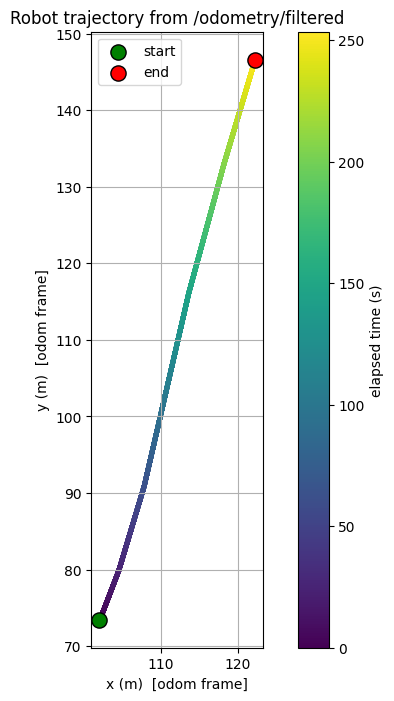

Points: 12675  |  path duration: 253.480 s  |  straight-line start->end distance: 75.906 m


In [12]:
%matplotlib inline
import math

import numpy as np
import matplotlib.pyplot as plt

with AnyReader([BAG_PATH]) as reader:
    odom_conns = [c for c in reader.connections if c.topic == "/odometry/filtered"]
    if not odom_conns:
        raise RuntimeError("No connection found for topic '/odometry/filtered'")

    xs, ys, ts = [], [], []
    for connection, timestamp, rawdata in reader.messages(connections=odom_conns):
        msg = reader.deserialize(rawdata, connection.msgtype)
        xs.append(msg.pose.pose.position.x)
        ys.append(msg.pose.pose.position.y)

        stamp = msg.header.stamp
        stamp_t = stamp.sec + stamp.nanosec * 1e-9
        # Fall back to the bag timestamp if the header stamp is unset (0).
        ts.append(stamp_t if stamp_t > 0 else timestamp * 1e-9)

xs = np.asarray(xs)
ys = np.asarray(ys)
ts = np.asarray(ts)
elapsed = ts - ts[0]

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(xs, ys, c=elapsed, cmap="viridis", s=6)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("elapsed time (s)")

ax.scatter(xs[0], ys[0], c="green", s=120, edgecolor="black",
           zorder=5, label="start")
ax.scatter(xs[-1], ys[-1], c="red", s=120, edgecolor="black",
           zorder=5, label="end")

ax.set_aspect("equal")
ax.set_xlabel("x (m)  [odom frame]")
ax.set_ylabel("y (m)  [odom frame]")
ax.set_title("Robot trajectory from /odometry/filtered")
ax.grid(True)
ax.legend()
plt.show()

duration = elapsed[-1] - elapsed[0]
straight_line = math.hypot(xs[-1] - xs[0], ys[-1] - ys[0])
print(f"Points: {len(xs)}  |  path duration: {duration:.3f} s  |  "
      f"straight-line start->end distance: {straight_line:.3f} m")

## 8. LiDAR scan â€” top-down (from /os0_cloud_node/points)

The first `/os0_cloud_node/points` message is a `PointCloud2` with `point_step` 32 bytes and float32 fields x/y/z (offsets 0/4/8) and intensity (offset 16). We parse `msg.data` with a numpy structured dtype and render a top-down (x vs y) scatter in the `os0_lidar` frame, colored by intensity.

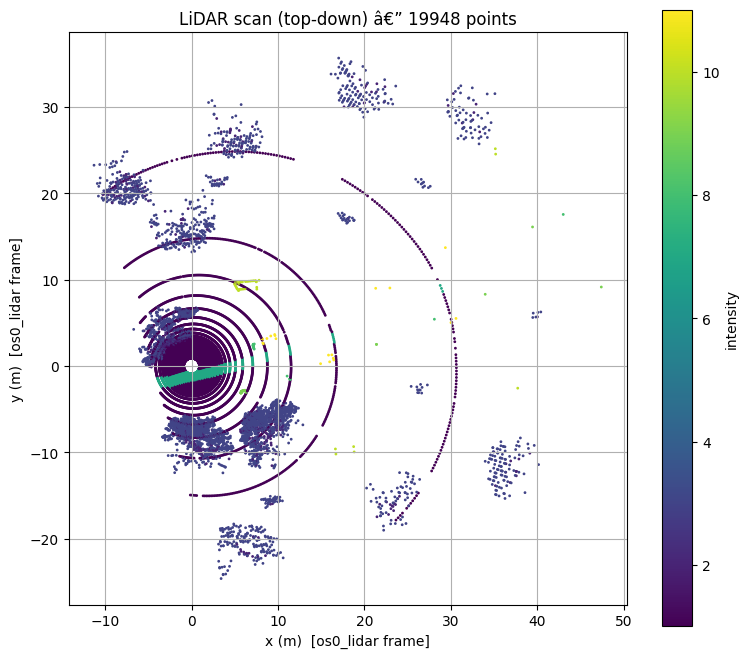

Points parsed: 19948 of 19948  |  x range: [-11.28, 47.42] m  |  y range: [-24.59, 35.64] m  |  intensity: [1.00, 11.00]


In [13]:
with AnyReader([BAG_PATH]) as reader:
    pc_conns = [c for c in reader.connections if c.topic == "/os0_cloud_node/points"]
    if not pc_conns:
        raise RuntimeError("No connection found for topic '/os0_cloud_node/points'")

    cloud = None
    for connection, timestamp, rawdata in reader.messages(connections=pc_conns):
        cloud = reader.deserialize(rawdata, connection.msgtype)
        break

if cloud is None:
    raise RuntimeError("Could not read a message from '/os0_cloud_node/points'")

point_step = cloud.point_step
pt_dtype = np.dtype({
    "names": ["x", "y", "z", "intensity"],
    "formats": ["<f4", "<f4", "<f4", "<f4"],
    "offsets": [0, 4, 8, 16],
    "itemsize": point_step,
})
points = np.frombuffer(bytes(cloud.data), dtype=pt_dtype)

# Drop NaN/inf points before plotting.
finite = (
    np.isfinite(points["x"]) & np.isfinite(points["y"])
    & np.isfinite(points["z"]) & np.isfinite(points["intensity"])
)
px = points["x"][finite]
py = points["y"][finite]
intensity = points["intensity"][finite]

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(px, py, c=intensity, cmap="viridis", s=1)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("intensity")

ax.set_aspect("equal")
ax.set_xlabel("x (m)  [os0_lidar frame]")
ax.set_ylabel("y (m)  [os0_lidar frame]")
ax.set_title(f"LiDAR scan (top-down) â€” {len(px)} points")
ax.grid(True)
plt.show()

print(f"Points parsed: {len(px)} of {len(points)}  |  "
      f"x range: [{px.min():.2f}, {px.max():.2f}] m  |  "
      f"y range: [{py.min():.2f}, {py.max():.2f}] m  |  "
      f"intensity: [{intensity.min():.2f}, {intensity.max():.2f}]")

## 9. Animated LiDAR along trajectory (world frame)

Every 10th `/os0_cloud_node/points` scan is transformed from the local `os0_lidar` frame into the `odom` world frame using the robot pose (position + yaw) interpolated from `/odometry/filtered` at each scan's timestamp. The result is rendered as an animated GIF: the moving point cloud (colored by intensity) sweeps along the full trajectory, with a robot marker and a growing trail. Because `ffmpeg` is unavailable, the animation is written with matplotlib's **pillow** writer.

In [14]:
# NOTE: This cell is EXPENSIVE to run. It renders a GIF over hundreds of frames
# (every 10th LiDAR scan, each transformed into the odom world frame) using the
# matplotlib pillow writer. Expect it to take several minutes and use a fair
# amount of memory (all subsampled scans are held in RAM).

import matplotlib.animation as animation

GIF_PATH = Path(r"e:\Husky viz\park_1_lidar_trajectory.gif")
LIDAR_STRIDE = 10          # keep every 10th /os0_cloud_node/points message
MAX_POINTS_PER_SCAN = 4000  # deterministic subsample cap per scan
LIDAR_RANGE_MARGIN = 40.0   # metres of padding around trajectory extent
FPS = 10

# --- 1. Collect the full trajectory (timestamp, x, y, yaw) --------------------
with AnyReader([BAG_PATH]) as reader:
    odom_conns = [c for c in reader.connections if c.topic == "/odometry/filtered"]
    if not odom_conns:
        raise RuntimeError("No connection found for topic '/odometry/filtered'")

    pose_t, pose_x, pose_y, pose_yaw = [], [], [], []
    for connection, timestamp, rawdata in reader.messages(connections=odom_conns):
        msg = reader.deserialize(rawdata, connection.msgtype)

        stamp = msg.header.stamp
        stamp_t = stamp.sec + stamp.nanosec * 1e-9
        t = stamp_t if stamp_t > 0 else timestamp * 1e-9

        px_pos = msg.pose.pose.position.x
        py_pos = msg.pose.pose.position.y

        # Quaternion components named to avoid clashing with position x/y.
        q = msg.pose.pose.orientation
        x_q, y_q, z_q, w_q = q.x, q.y, q.z, q.w
        yaw = math.atan2(2.0 * (w_q * z_q + x_q * y_q),
                         1.0 - 2.0 * (y_q ** 2 + z_q ** 2))

        pose_t.append(t)
        pose_x.append(px_pos)
        pose_y.append(py_pos)
        pose_yaw.append(yaw)

pose_t = np.asarray(pose_t)
pose_x = np.asarray(pose_x)
pose_y = np.asarray(pose_y)
pose_yaw = np.asarray(pose_yaw)

# Sort trajectory arrays by timestamp (required for np.interp).
order = np.argsort(pose_t)
pose_t = pose_t[order]
pose_x = pose_x[order]
pose_y = pose_y[order]
pose_yaw = pose_yaw[order]

# --- 2. Collect subsampled LiDAR scans (every 10th message) ------------------
pt_dtype = None  # built from the first scan's point_step
frames = []      # list of dicts: {t, lx, ly, intensity}

with AnyReader([BAG_PATH]) as reader:
    pc_conns = [c for c in reader.connections if c.topic == "/os0_cloud_node/points"]
    if not pc_conns:
        raise RuntimeError("No connection found for topic '/os0_cloud_node/points'")

    for idx, (connection, timestamp, rawdata) in enumerate(
        reader.messages(connections=pc_conns)
    ):
        if idx % LIDAR_STRIDE != 0:
            continue

        cloud = reader.deserialize(rawdata, connection.msgtype)

        # Same structured-dtype parsing approach as Section 8.
        if pt_dtype is None:
            pt_dtype = np.dtype({
                "names": ["x", "y", "z", "intensity"],
                "formats": ["<f4", "<f4", "<f4", "<f4"],
                "offsets": [0, 4, 8, 16],
                "itemsize": cloud.point_step,
            })

        points = np.frombuffer(bytes(cloud.data), dtype=pt_dtype)
        finite = (
            np.isfinite(points["x"]) & np.isfinite(points["y"])
            & np.isfinite(points["z"]) & np.isfinite(points["intensity"])
        )
        lx = points["x"][finite]
        ly = points["y"][finite]
        li = points["intensity"][finite]

        # Deterministic subsample down to ~MAX_POINTS_PER_SCAN via a fixed stride.
        if lx.shape[0] > MAX_POINTS_PER_SCAN:
            step = int(np.ceil(lx.shape[0] / MAX_POINTS_PER_SCAN))
            lx = lx[::step]
            ly = ly[::step]
            li = li[::step]

        stamp = cloud.header.stamp
        stamp_t = stamp.sec + stamp.nanosec * 1e-9
        t = stamp_t if stamp_t > 0 else timestamp * 1e-9

        frames.append({"t": t, "lx": lx, "ly": ly, "intensity": li})

if not frames:
    raise RuntimeError("No LiDAR frames collected â€” nothing to animate.")

# --- 3. Interpolate pose per frame & transform scan into odom world frame ----
for f in frames:
    fx = np.interp(f["t"], pose_t, pose_x)
    fy = np.interp(f["t"], pose_t, pose_y)
    fyaw = np.interp(f["t"], pose_t, pose_yaw)

    c, s = math.cos(fyaw), math.sin(fyaw)
    f["world_x"] = fx + (f["lx"] * c - f["ly"] * s)
    f["world_y"] = fy + (f["lx"] * s + f["ly"] * c)
    f["pose_x"] = fx
    f["pose_y"] = fy

# --- 4. Build the animation ---------------------------------------------------
t0 = pose_t[0]

# Fixed axis limits: trajectory extent plus a LiDAR range margin.
x_min = pose_x.min() - LIDAR_RANGE_MARGIN
x_max = pose_x.max() + LIDAR_RANGE_MARGIN
y_min = pose_y.min() - LIDAR_RANGE_MARGIN
y_max = pose_y.max() + LIDAR_RANGE_MARGIN

# Shared intensity color scale across all frames.
imin = min(float(f["intensity"].min()) for f in frames if f["intensity"].size)
imax = max(float(f["intensity"].max()) for f in frames if f["intensity"].size)

fig, ax = plt.subplots(figsize=(9, 8))

# Static: full trajectory as a thin grey line, drawn once.
ax.plot(pose_x, pose_y, color="grey", linewidth=0.6, zorder=1)

# Persistent artists updated each frame.
scat = ax.scatter([], [], c=[], cmap="viridis", s=1,
                  vmin=imin, vmax=imax, zorder=2)
(trail_line,) = ax.plot([], [], color="tab:blue", linewidth=1.5, zorder=3)
(robot_marker,) = ax.plot([], [], marker="o", color="red", markersize=8,
                          markeredgecolor="black", linestyle="None", zorder=4)

cbar = fig.colorbar(scat, ax=ax)
cbar.set_label("intensity")

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)  [odom frame]")
title = ax.set_title("")
ax.grid(True)


def update(i):
    f = frames[i]
    offsets = np.column_stack((f["world_x"], f["world_y"]))
    scat.set_offsets(offsets)
    scat.set_array(f["intensity"])

    # Trailing trajectory up to the current scan time.
    upto = pose_t <= f["t"]
    trail_line.set_data(pose_x[upto], pose_y[upto])

    robot_marker.set_data([f["pose_x"]], [f["pose_y"]])

    elapsed = f["t"] - t0
    title.set_text(f"LiDAR in odom frame â€” frame {i + 1}/{len(frames)}  "
                   f"(t = {elapsed:.1f} s)")
    return scat, trail_line, robot_marker, title


anim = animation.FuncAnimation(
    fig, update, frames=len(frames), interval=1000 // FPS, blit=False
)

anim.save(GIF_PATH, writer="pillow", fps=FPS)
plt.close(fig)

print(f"Animation frames: {len(frames)}")
print(f"Saved GIF to:     {GIF_PATH}")
print("Note: rendering this GIF may take several minutes.")

Animation frames: 254
Saved GIF to:     e:\Husky viz\park_1_lidar_trajectory.gif
Note: rendering this GIF may take several minutes.


## 10. GPS track + mission waypoints

The full `/navsat/fix` GPS track is plotted as longitude (x) vs latitude (y), colored by elapsed time. The mission waypoints from the first `/navigation/objetive_gps` message (a `Float64MultiArray` whose flat `.data` reshapes to `(N, 2)` rows) are overlaid as red stars and annotated by index.

**Waypoint ordering:** the sample values (e.g. `49.900â€¦, 8.899â€¦`) show each row is `(lat, lon)` â€” latitude first â€” so waypoints are plotted at `(lon, lat)` to match the GPS axes. No equal aspect is forced (degrees of lat and lon are not equal distances).

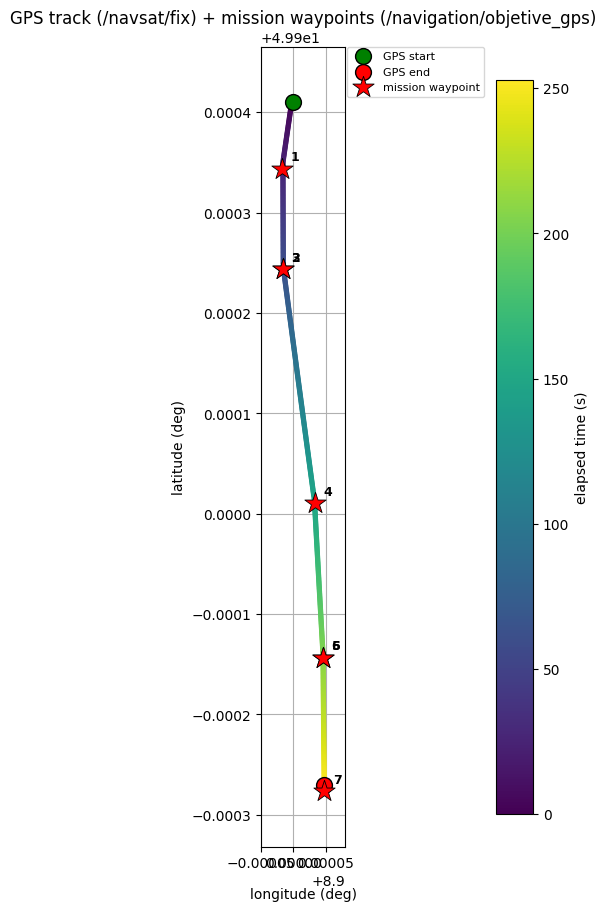

GPS fixes:        507
Mission waypoints: 7
GPS bounding box:
    longitude: [8.899984, 8.900048] deg
    latitude:  [49.899730, 49.900410] deg
Waypoints (index: lat, lon):
    1: 49.900344, 8.899983
    2: 49.900244, 8.899985
    3: 49.900244, 8.899985
    4: 49.900010, 8.900033
    5: 49.899857, 8.900046
    6: 49.899857, 8.900046
    7: 49.899723, 8.900048


In [15]:
# --- 1. Full GPS track from /navsat/fix (lon, lat, elapsed time) -------------
with AnyReader([BAG_PATH]) as reader:
    fix_conns = [c for c in reader.connections if c.topic == "/navsat/fix"]
    if not fix_conns:
        raise RuntimeError("No connection found for topic '/navsat/fix'")

    lons, lats, fix_ts = [], [], []
    for connection, timestamp, rawdata in reader.messages(connections=fix_conns):
        msg = reader.deserialize(rawdata, connection.msgtype)
        lons.append(msg.longitude)
        lats.append(msg.latitude)

        stamp = msg.header.stamp
        stamp_t = stamp.sec + stamp.nanosec * 1e-9
        # Fall back to the bag timestamp if the header stamp is unset (0).
        fix_ts.append(stamp_t if stamp_t > 0 else timestamp * 1e-9)

lons = np.asarray(lons)
lats = np.asarray(lats)
fix_ts = np.asarray(fix_ts)
fix_elapsed = fix_ts - fix_ts[0]

# --- 2. First /navigation/objetive_gps message: waypoints (lat, lon) rows ----
with AnyReader([BAG_PATH]) as reader:
    wp_conns = [c for c in reader.connections if c.topic == "/navigation/objetive_gps"]
    if not wp_conns:
        raise RuntimeError("No connection found for topic '/navigation/objetive_gps'")

    wp_msg = None
    for connection, timestamp, rawdata in reader.messages(connections=wp_conns):
        wp_msg = reader.deserialize(rawdata, connection.msgtype)
        break

if wp_msg is None:
    raise RuntimeError("Could not read a message from '/navigation/objetive_gps'")

# Flat float64 array -> (N, 2) rows of (lat, lon); see markdown ordering note.
waypoints = np.asarray(wp_msg.data, dtype=float).reshape(-1, 2)
wp_lat = waypoints[:, 0]
wp_lon = waypoints[:, 1]

# --- 3. Plot: GPS track colored by time + waypoint stars ---------------------
# Use constrained layout: it accounts for the axis offset text, the colorbar,
# and an out-of-axes legend, so nothing is clipped at the figure edges the way
# tight_layout() was clipping the title, x-label, and legend.
fig, ax = plt.subplots(figsize=(5, 9), layout="constrained")

sc = ax.scatter(lons, lats, c=fix_elapsed, cmap="viridis", s=8, zorder=2)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("elapsed time (s)")

# clip_on=False so a marker sitting exactly on an axis limit is drawn in full
# rather than sliced by the frame (belt-and-suspenders against edge clipping).
ax.scatter(lons[0], lats[0], c="green", s=130, edgecolor="black",
           zorder=4, clip_on=False, label="GPS start")
ax.scatter(lons[-1], lats[-1], c="red", s=130, edgecolor="black",
           zorder=4, clip_on=False, label="GPS end")

ax.scatter(wp_lon, wp_lat, marker="*", c="red", s=260, edgecolor="black",
           linewidth=0.6, zorder=5, clip_on=False, label="mission waypoint")
for i, (wlon, wlat) in enumerate(zip(wp_lon, wp_lat), start=1):
    ax.annotate(str(i), (wlon, wlat), textcoords="offset points",
                xytext=(6, 6), fontsize=9, fontweight="bold", zorder=6)

# Apply the correct geographic aspect ratio. One degree of LONGITUDE covers
# only cos(latitude) times the ground distance of one degree of LATITUDE, so
# equal-aspect on raw degrees would stretch the east motion and distort the
# true shape. Setting aspect = 1/cos(lat) on the degree axes makes one meter
# north and one meter east occupy equal screen distance (geographically true).
lat0 = float(np.mean(lats))  # reference latitude (mean of the fixes)
ax.set_aspect(1.0 / math.cos(math.radians(lat0)))

# Set EXPLICIT axis limits with generous padding. ax.margins() is ineffective
# under the aspect lock: the fixed aspect forces the x-range tight so the
# margin never takes effect on x, and the fat markers straddle the frame and
# get sliced. Instead compute the extents from BOTH the fix track and the
# waypoints (so edge waypoint stars aren't cut) and pad them explicitly.
lon_min = min(lons.min(), wp_lon.min())
lon_max = max(lons.max(), wp_lon.max())
lat_min = min(lats.min(), wp_lat.min())
lat_max = max(lats.max(), wp_lat.max())
lon_pad = max((lon_max - lon_min) * 0.5, 1e-5)  # generous: x-span is tiny
lat_pad = (lat_max - lat_min) * 0.08
ax.set_xlim(lon_min - lon_pad, lon_max + lon_pad)
ax.set_ylim(lat_min - lat_pad, lat_max + lat_pad)

# Extra labelpad keeps the x-axis label clear of the axis offset text
# (e.g. "1e-5 +8.9") that sits just below the tick labels.
ax.set_xlabel("longitude (deg)", labelpad=12)
ax.set_ylabel("latitude (deg)")
ax.set_title("GPS track (/navsat/fix) + mission waypoints (/navigation/objetive_gps)")
ax.grid(True)
# The aspect lock renders the path as a thin stick on the LEFT of the axes,
# leaving the right-center area empty. Place the legend there (between the path
# and the colorbar) so it never overlaps the title or the plotted path.
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0),
          borderaxespad=0, fontsize=8)
plt.show()

print(f"GPS fixes:        {len(lons)}")
print(f"Mission waypoints: {len(waypoints)}")
print("GPS bounding box:")
print(f"    longitude: [{lons.min():.6f}, {lons.max():.6f}] deg")
print(f"    latitude:  [{lats.min():.6f}, {lats.max():.6f}] deg")
print("Waypoints (index: lat, lon):")
for i, (wlat, wlon) in enumerate(zip(wp_lat, wp_lon), start=1):
    print(f"    {i}: {wlat:.6f}, {wlon:.6f}")


## 11. Speed over time (from /odometry/filtered)

The commanded/estimated body velocities from every `/odometry/filtered` message: forward speed `twist.twist.linear.x` (m/s) and yaw rate `twist.twist.angular.z` (rad/s), plotted against elapsed time in two stacked, x-shared subplots.

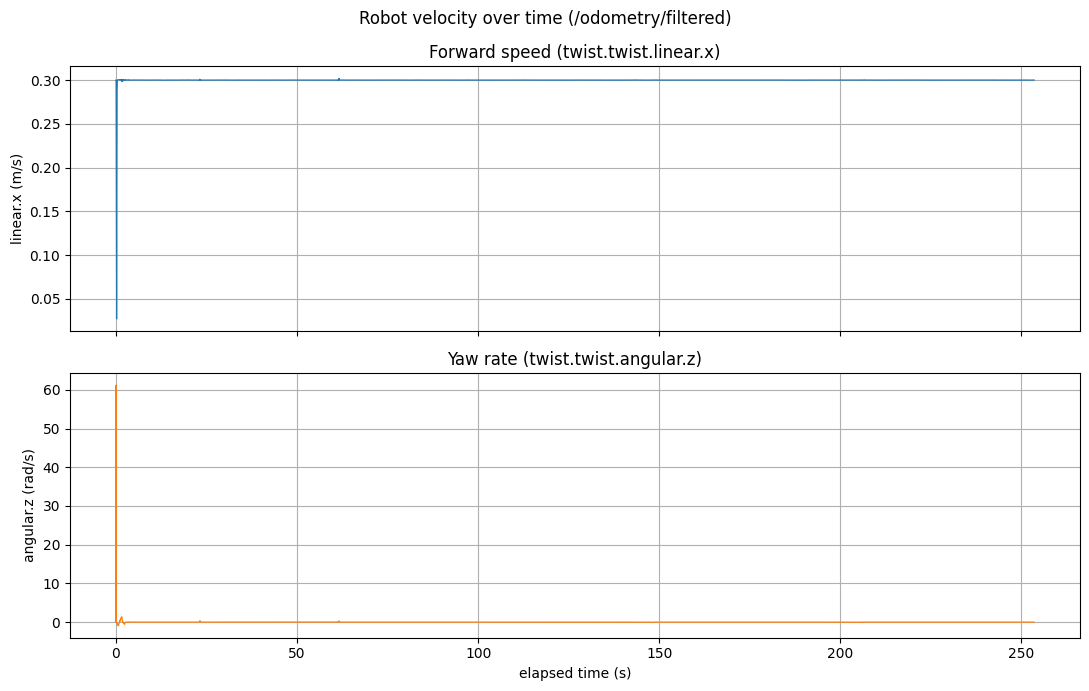

Samples: 12675  |  duration: 253.480 s

Linear speed (m/s):
    mean=0.2999  min=0.0270  max=0.3020
Angular rate (rad/s):
    mean=0.0054  min=-0.9237  max=61.2189


In [16]:
with AnyReader([BAG_PATH]) as reader:
    odom_conns = [c for c in reader.connections if c.topic == "/odometry/filtered"]
    if not odom_conns:
        raise RuntimeError("No connection found for topic '/odometry/filtered'")

    vel_ts, lin_x, ang_z = [], [], []
    for connection, timestamp, rawdata in reader.messages(connections=odom_conns):
        msg = reader.deserialize(rawdata, connection.msgtype)
        lin_x.append(msg.twist.twist.linear.x)
        ang_z.append(msg.twist.twist.angular.z)

        stamp = msg.header.stamp
        stamp_t = stamp.sec + stamp.nanosec * 1e-9
        # Fall back to the bag timestamp if the header stamp is unset (0).
        vel_ts.append(stamp_t if stamp_t > 0 else timestamp * 1e-9)

vel_ts = np.asarray(vel_ts)
lin_x = np.asarray(lin_x)
ang_z = np.asarray(ang_z)
vel_elapsed = vel_ts - vel_ts[0]

fig, (ax_lin, ax_ang) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax_lin.plot(vel_elapsed, lin_x, color="tab:blue", linewidth=0.9)
ax_lin.set_ylabel("linear.x (m/s)")
ax_lin.set_title("Forward speed (twist.twist.linear.x)")
ax_lin.grid(True)

ax_ang.plot(vel_elapsed, ang_z, color="tab:orange", linewidth=0.9)
ax_ang.set_xlabel("elapsed time (s)")
ax_ang.set_ylabel("angular.z (rad/s)")
ax_ang.set_title("Yaw rate (twist.twist.angular.z)")
ax_ang.grid(True)

fig.suptitle("Robot velocity over time (/odometry/filtered)")
plt.tight_layout()
plt.show()

print(f"Samples: {len(vel_elapsed)}  |  duration: {vel_elapsed[-1]:.3f} s\n")
print("Linear speed (m/s):")
print(f"    mean={lin_x.mean():.4f}  min={lin_x.min():.4f}  max={lin_x.max():.4f}")
print("Angular rate (rad/s):")
print(f"    mean={ang_z.mean():.4f}  min={ang_z.min():.4f}  max={ang_z.max():.4f}")